In [1]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict, Literal

In [2]:
class QuadState(TypedDict):

    a: int
    b: int
    c: int  

    eq: str
    d: float
    res: str

In [8]:
def show_eq(state: QuadState):
    eq = f'{state['a']}x^2 + {state['b']}x + {state['c']}'

    return {
        "eq": eq,
    }

def calc_d(state: QuadState): 

    d = state['b']**2 - 4*state['a']*state['c']
    return {
        'd': d
    }

def real_roots(state: QuadState):

    root1 = (-state["b"] + state["d"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["d"]**0.5)/(2*state["a"])

    res = f'The roots are {root1} and {root2}'
    return {
        "res": res
    }

def repeated_roots(state: QuadState):

    root = (-state["b"])/(2*state["a"])
    res = f'Only repeating root is {root}'

    return {
        "res": res
    }

def no_real_roots(state: QuadState):
    
    res = f'No real roots'
    return {
        "res": res
    }

def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:

    if state['d'] > 0:
        return "real_roots"
    elif state['d'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [9]:
graph = StateGraph(QuadState)

graph.add_node('show_eq', show_eq)
graph.add_node('calc_d', calc_d)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'show_eq')
graph.add_edge('show_eq', 'calc_d')

graph.add_conditional_edges('calc_d', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

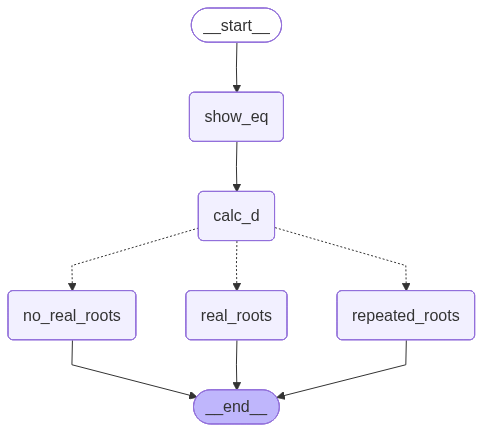

In [10]:
workflow = graph.compile()
workflow

In [11]:
initial_state = {
    'a': 1,
    'b': -5,
    'c': 6,
}
workflow.invoke(initial_state)

{'a': 1,
 'b': -5,
 'c': 6,
 'eq': '1x^2 + -5x + 6',
 'd': 1,
 'res': 'The roots are 3.0 and 2.0'}